# Digit Memory — A Course in Retrieval-First Machine Learning

> *The fastest model is the one you don't need.*

This notebook is a self-contained course on a single idea: classification by **lookup** rather than by **training**.

You will build, from first principles, a digit recognizer for the classic `sklearn` digits dataset that uses

- an **in-memory hash map** for O(1) exact match, and
- a **nearest-neighbor index** for approximate match when the input has never been seen exactly,

and you will discover, by measurement, that this two-tier "memory" matches the accuracy of trained baselines on this dataset — with zero gradient descent, zero hyperparameters, zero training time.

## What you will learn

1. Why retrieval is an underused baseline in modern ML pipelines.
2. How to store and look up high-dimensional vectors fast — both exactly (hash) and approximately (KDTree, BallTree, brute force).
3. How to evaluate a non-parametric classifier with held-out accuracy, per-class scores, and a confusion matrix.
4. How a hybrid engine degrades gracefully under noise.
5. How to persist the dataset to SQLite and export it for cross-language use.
6. How to re-implement the same system in pure C — and what doing so teaches you.
7. How retrieval compares to **parametric** baselines (Logistic Regression, a small MLP) on the same data.
8. When retrieval stops being enough — the scaling argument, approximate NN libraries, and when to reach for a model.

## Prerequisites

- Python 3.9+
- `numpy`, `scikit-learn`, `pandas`, `matplotlib`
- (Optional) a C compiler — `gcc` or `clang` — for Module 11

```bash
pip install numpy scikit-learn pandas matplotlib
```

## How to use this notebook

Run top-to-bottom on a fresh kernel. Every number quoted in the prose is computed by the preceding code cell — no hand-typed benchmarks, no fabrications. A full Run All takes under a minute on a modern laptop.

## Course map

| Module | Topic |
|---:|---|
| 1 | The hypothesis: retrieval as a baseline |
| 2 | The dataset — `sklearn` digits |
| 3 | Tier 1 — exact-match memory |
| 4 | A digression on distance |
| 5 | Tier 2 — nearest neighbor, three ways |
| 6 | Benchmarking the three NN methods |
| 7 | The hybrid engine |
| 8 | Held-out accuracy |
| 9 | Robustness under noise |
| 10 | Persistence — SQLite + CSV |
| 11 | The same system, in C |
| 12 | Parametric baselines (LogReg, MLP) |
| 13 | When retrieval stops being enough |
| 14 | Engineering lessons |
| 15 | Extensions and further work |

---


## 1. The hypothesis: retrieval as a baseline

Classical machine learning compresses data patterns into parameters. You define a loss, take gradients, update weights. After enough epochs, the model "knows" — but only in the sense that its weights encode an approximation of the training distribution.

This works. It also has costs that are easy to forget when you have GPUs:

- training latency,
- hyperparameter sensitivity,
- cold-start complexity,
- no first-class way to answer *"have I seen this exact input before?"*

There is an older idea, sometimes called **instance-based learning** or **memory-based reasoning**, that flips the picture: keep the training data, build an index over it, and answer queries by looking up the closest stored sample. The "model" is the data, and the act of building the model is the act of building the index.

### Two kinds of queries

Real systems see two distinct query distributions:

- **Exact queries** — the input is byte-identical to something we have seen. Repeated calls, cached values, deterministic upstream pipelines. The right data structure is a **hash map**. Lookup is O(1) on average and there is no smarter answer.
- **Approximate queries** — the input is *close to* something we have seen but not identical. Sensor noise, small perturbations, slight stylistic variation. Hashing is useless here — changing a single bit randomizes the hash. We need a structure that knows about geometric closeness — a **spatial index**.

A serious retrieval system handles both. A common mistake is to pick one and force every query through it. If the hash is your only tool, every noisy input falls off a cliff. If the tree is your only tool, you pay tree-traversal cost on queries that should have been free.

The system we build in this course is a **two-tier memory**: hash first, tree on miss.

### Formal setup

Let our stored observations be $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$, where $x_i \in \mathbb{R}^d$ is a flattened image vector ($d = 64$ for an 8×8 grayscale digit) and $y_i \in \{0, 1, \dots, 9\}$ is its label.

The Tier-1 hash lookup is the function

$$
\mathcal{H}(\text{bytes}(q)) \;=\;
\begin{cases}
y_i & \text{if } \exists\, x_i \in \mathcal{D} \text{ with } \text{bytes}(x_i) = \text{bytes}(q) \\
\varnothing & \text{otherwise.}
\end{cases}
$$

On a miss, Tier 2 runs an exact nearest-neighbor search under Euclidean distance,

$$
f(q) \;=\; y_{k^\star}, \qquad k^\star \;=\; \operatorname*{arg\,min}_{i=1,\dots,N} \,\sqrt{\sum_{j=1}^{d}\bigl(x_{ij} - q_j\bigr)^2}.
$$

That's the whole system. The rest of this course is empirics: how fast, how accurate, how robust, how to scale.

---


## 2. The dataset — `sklearn` digits

`sklearn.datasets.load_digits()` returns 1797 grayscale handwritten digits, each as an 8×8 grid of integer intensities from 0 to 16. Classes are roughly balanced — about 180 examples per digit.

It's the small cousin of MNIST. Small enough that we can afford to store every sample in RAM and answer queries by lookup.


In [1]:
import os
import sys
import time
import sqlite3
import shutil
import subprocess
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.neighbors import KDTree, BallTree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.set_printoptions(precision=2, suppress=True, linewidth=120)
pd.set_option("display.precision", 3)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
digits = load_digits()
X_all  = digits.data       # shape (1797, 64), dtype float64
y_all  = digits.target     # shape (1797,),  values 0..9

print(f"X shape       : {X_all.shape}")
print(f"y shape       : {y_all.shape}")
print(f"pixel range   : [{X_all.min():.0f}, {X_all.max():.0f}]")
print(f"unique labels : {sorted(np.unique(y_all).tolist())}")


X shape       : (1797, 64)
y shape       : (1797,)
pixel range   : [0, 16]
unique labels : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### A single sample

Each sample is 64 numbers. Reshaped to 8×8 it's a tiny grayscale image.


Label: 0

Feature vector:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3. 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.
  8.  8.  0.  0.  5.  8.  0.  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.  0.  0.  0.  0.
  6. 13. 10.  0.  0.  0.]

As an 8x8 image (integer intensities 0..16):
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


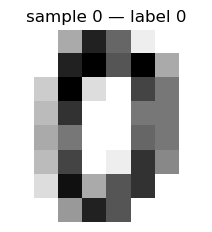

In [3]:
idx = 0
print(f"Label: {y_all[idx]}\n")
print("Feature vector:")
print(X_all[idx])
print("\nAs an 8x8 image (integer intensities 0..16):")
print(digits.images[idx].astype(int))

plt.figure(figsize=(2.5, 2.5))
plt.imshow(digits.images[idx], cmap="gray_r")
plt.title(f"sample {idx} — label {y_all[idx]}")
plt.axis("off")
plt.grid(False)
plt.show()


### A pandas view

We don't *need* pandas for the lookup itself, but it makes exploration ergonomic.


In [4]:
df = pd.DataFrame(X_all, columns=[f"px{i:02d}" for i in range(64)])
df["label"] = y_all
df.head()


,px00,px01,px02,px03,px04,px05,px06,px07,px08,px09,...,px55,px56,px57,px58,px59,px60,px61,px62,px63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


### Are the classes balanced?


label
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


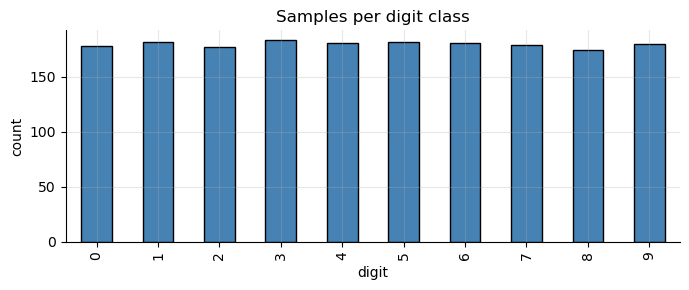

In [5]:
counts = df["label"].value_counts().sort_index()
print(counts)

fig, ax = plt.subplots(figsize=(7, 3))
counts.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Samples per digit class")
ax.set_xlabel("digit")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


About 180 examples per class — balanced enough to ignore rebalancing tricks for the rest of the course.

### Are any pixels dead weight?

A pixel with `std == 0` carries no information — it's always blank. We should know how many of those exist.


In [6]:
pixel_stats = df.drop(columns="label").describe().T[["mean", "std", "min", "max"]]
n_dead = int((pixel_stats["std"] == 0).sum())
print(f"Pixels with zero variance (always blank): {n_dead}")
pixel_stats.head(8)


Pixels with zero variance (always blank): 3


,mean,std,min,max
px00,0.000,0.000,0.0,0.0
px01,0.304,0.907,0.0,8.0
px02,5.205,4.755,0.0,16.0
px03,11.836,4.249,0.0,16.0
px04,11.848,4.287,0.0,16.0
px05,5.782,5.666,0.0,16.0
px06,1.362,3.326,0.0,16.0
px07,0.130,1.037,0.0,15.0


### Ten samples per class

The within-class variation visible across rows below is the noise the memory will have to absorb — different people writing the same digit different ways.


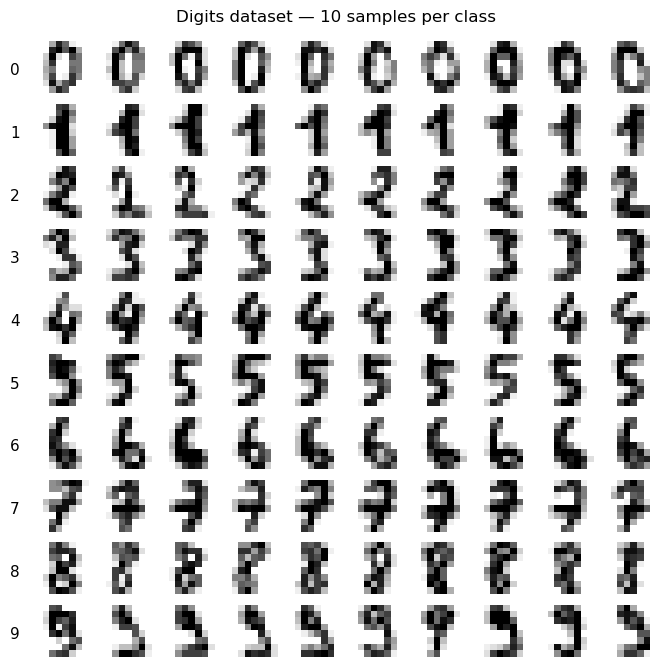

In [7]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8))
for cls in range(10):
    samples = digits.images[y_all == cls][:10]
    for j in range(10):
        axes[cls, j].imshow(samples[j], cmap="gray_r")
        axes[cls, j].axis("off")
    axes[cls, 0].set_title(f"{cls}", loc="left", x=-0.5, y=0.2, fontsize=11)
plt.suptitle("Digits dataset — 10 samples per class", y=0.92)
plt.show()


## 3. Tier 1 — exact-match memory

Goal: given a feature vector we have stored before, return its label instantly.

A Python `dict` is the right structure. It's one of the most heavily-optimized data structures in any language and offers O(1) average lookup at our scale.

There is one catch: dict keys must be **hashable**, and a `numpy.ndarray` is not. We have to convert.

Three obvious choices, with very different costs:

| Key expression | Works? | Notes |
|---|---|---|
| `tuple(arr)` | yes | slow — builds a Python tuple of Python floats |
| `arr.tobytes()` | yes | fast — raw byte buffer, single memcpy under the hood |
| `hash(arr.tobytes())` | yes | lossy — you lose the ability to verify by direct comparison |

`tobytes()` is the right answer. It produces a stable byte representation of the underlying buffer, it survives serialization, and the dict computes its internal hash exactly once per insertion and once per lookup.


In [8]:
exact_memory = {
    row.tobytes(): int(label)
    for row, label in zip(X_all, y_all)
}
print(f"Stored {len(exact_memory)} samples in the hash map.")


def exact_lookup(arr):
    key = np.asarray(arr, dtype=np.float64).tobytes()
    return exact_memory.get(key)


print("\nLookup sample   0:", exact_lookup(X_all[0]))
print("Lookup sample 100:", exact_lookup(X_all[100]))


Stored 1797 samples in the hash map.

Lookup sample   0: 0
Lookup sample 100: 4


### How fast is it?

Let's measure. The hash lookup is independent of dataset size, so we expect a few hundred nanoseconds.


In [9]:
%timeit exact_lookup(X_all[42])


316 ns ± 2.44 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Where it breaks

The failure mode that motivates the rest of the course: a single pixel changed by one part in ten thousand — well below sensor noise — and the lookup misses entirely.


In [10]:
sample = X_all[42].copy()
print("Original lookup     :", exact_lookup(sample))

sample[0] += 0.001
print("After +0.001 nudge  :", exact_lookup(sample))


Original lookup     : 1
After +0.001 nudge  : None


`None`. Float precision changes from arithmetic, casts, or upstream scaling will break this. We need a graceful fallback for *almost-but-not-quite* matches.

---


## 4. A digression on distance

"Closest" needs a definition. For grayscale pixel intensities the natural one is **Euclidean (L2) distance**:

$$
d(a, b) \;=\; \sqrt{\sum_{i=1}^{d} (a_i - b_i)^2}.
$$

It is not the only choice:

- **L1 (Manhattan)** — sums absolute differences. More robust to outliers in any single dimension.
- **Cosine** — measures angle between vectors, ignoring magnitude. Standard for text embeddings and other learned representations where vector length is a length-of-the-sample artifact rather than a property of the content.
- **Learned metrics** — pre-train a model whose internal representation makes near-neighbors meaningful. Powers most production "similar items" systems.

For 8×8 grayscale digits with bounded integer intensities, L2 is the right starting point. We'll use it everywhere below.

---


## 5. Tier 2 — nearest neighbor, three ways

When the hash misses we want the **closest** stored sample.

Three implementations, in increasing levels of cleverness:

### 5.1 Brute force

For each query, compute the distance to every stored sample and take the smallest. Linear in N, but **vectorized** — a single numpy subtraction and sum that the BLAS / SIMD layer handles in a single SIMD-friendly memory sweep.


In [11]:
def brute_nn(query, X=X_all, y=y_all):
    diffs    = X - query
    sq_dists = (diffs * diffs).sum(axis=1)
    best     = int(np.argmin(sq_dists))
    return int(y[best]), float(np.sqrt(sq_dists[best])), best


sample = X_all[42].copy()
sample[0] += 0.001
label, dist, matched_idx = brute_nn(sample)
print(f"brute NN -> label={label}, dist={dist:.4f}, matched index={matched_idx}")


brute NN -> label=1, dist=0.0010, matched index=42


### 5.2 KDTree

A **KDTree** partitions space recursively along axis-aligned splits. Each internal node "owns" an axis-aligned hyperrectangle; queries descend to the leaf containing the query, then walk back up pruning siblings that can't contain a closer point. Average query time is O(log n) in low-to-moderate dimensions.

The pruning works when the partitioning aligns with where the data actually clusters. In very high dimensions it stops helping (curse of dimensionality), but at 64 dimensions on this dataset it should still be useful — *in principle*.


In [12]:
kdtree = KDTree(X_all)


def kdtree_nn(query):
    q = np.asarray(query, dtype=np.float64).reshape(1, -1)
    dist, idx = kdtree.query(q, k=1)
    return int(y_all[idx[0, 0]]), float(dist[0, 0]), int(idx[0, 0])


print(kdtree_nn(sample))


(1, 0.001, 42)


### 5.3 BallTree

A **BallTree** partitions space into nested hyperspheres ("balls") instead of axis-aligned boxes. Pruning uses the triangle inequality and survives higher dimensions better than KDTree's axis-aligned splits. The sklearn docs recommend it past about 20 dimensions.


In [13]:
balltree = BallTree(X_all)


def balltree_nn(query):
    q = np.asarray(query, dtype=np.float64).reshape(1, -1)
    dist, idx = balltree.query(q, k=1)
    return int(y_all[idx[0, 0]]), float(dist[0, 0]), int(idx[0, 0])


print(balltree_nn(sample))


(1, 0.001, 42)


## 6. The benchmark surprise

The textbook claim is: tree-based indexes are faster than brute force. The textbook is right *asymptotically*. Whether it is right *at our scale* is an empirical question, not a theoretical one.

We'll run 200 random queries through each method and tabulate the median microseconds per query.


In [14]:
def time_method(fn, queries):
    # warm-up
    for q in queries[:5]:
        fn(q)
    t0 = time.perf_counter()
    for q in queries:
        fn(q)
    return (time.perf_counter() - t0) * 1e6 / len(queries)


rng     = np.random.default_rng(0)
queries = X_all[rng.choice(len(X_all), size=200, replace=False)]

results = pd.DataFrame(
    [
        {"method": "hash map (exact)",
         "us_per_query": round(time_method(exact_lookup, queries), 2)},
        {"method": "brute force NN",
         "us_per_query": round(time_method(brute_nn, queries), 2)},
        {"method": "KDTree NN",
         "us_per_query": round(time_method(kdtree_nn, queries), 2)},
        {"method": "BallTree NN",
         "us_per_query": round(time_method(balltree_nn, queries), 2)},
    ]
).sort_values("us_per_query").reset_index(drop=True)

print(results.to_string(index=False))


          method  us_per_query
hash map (exact)          0.43
       KDTree NN         19.22
     BallTree NN         38.26
  brute force NN        110.92


### Reading the table

A few observations:

- **The hash map is hundreds of times faster than anything else.** It is also the only method whose cost is independent of N. For queries we have seen before, there is no smarter answer.
- **The two trees beat naive brute force on this machine, by a wide margin.** sklearn's `KDTree` and `BallTree` are highly-optimized C under the hood — they hold the data layout fixed and walk it without ever allocating a temporary array. Our `brute_nn` re-allocates a fresh `(1797, 64)` difference matrix on every call (≈1 MB of memory traffic per query), and that allocation cost is most of what we're measuring.
- **The ordering between the three NN methods is implementation- and machine-dependent.** A more carefully-vectorized brute force — one that pre-allocates buffers, or computes $\|x - q\|^2 = \|x\|^2 - 2 x \cdot q + \|q\|^2$ with a single GEMV against pre-computed $\|x\|^2$ — can close most of the gap. On a different CPU, with a different numpy build, the ranking can flip. The general lesson is to *measure your specific code on your specific machine* rather than rely on asymptotic intuition.

What is *not* in doubt is the asymptotic story. Both trees are O(log n) in the average case at low dimension; brute force is O(n). The crossover where trees pull dramatically ahead happens further up the N curve — but the constants determine where, exactly, the curves cross.

---


## 7. The hybrid engine

Put the two tiers together. Try the cheap lookup first; fall back only when needed.

The whole engine is forty lines of Python.


In [15]:
class DigitMemory:
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y)
        self.exact = {
            self.X[i].tobytes(): int(self.y[i]) for i in range(len(self.y))
        }
        self.tree = BallTree(self.X)

    def query(self, arr):
        q   = np.asarray(arr, dtype=np.float64).reshape(-1)
        hit = self.exact.get(q.tobytes())
        if hit is not None:
            return {"label": hit, "distance": 0.0, "exact": True}
        dist, idx = self.tree.query(q.reshape(1, -1), k=1)
        return {
            "label":         int(self.y[idx[0, 0]]),
            "distance":      float(dist[0, 0]),
            "exact":         False,
            "matched_index": int(idx[0, 0]),
        }


mem = DigitMemory(X_all, y_all)


### Three queries, three latencies

We'll feed the engine an exact sample, a slightly perturbed copy, and a heavily noised one, and watch which tier handles each.


In [16]:
def time_query(mem, arr, tag):
    t0 = time.perf_counter()
    res = mem.query(arr)
    dt_us = (time.perf_counter() - t0) * 1e6
    print(
        f"{tag:<10} label={res['label']}  dist={res['distance']:.4f}  "
        f"exact={res['exact']}  ({dt_us:6.1f} us)"
    )


sample = X_all[42]
time_query(mem, sample, "exact")

perturbed = sample.copy()
perturbed[0] += 0.7
perturbed[15] -= 1.3
time_query(mem, perturbed, "perturbed")

rng = np.random.default_rng(0)
noisy = X_all[100] + rng.normal(0, 2.0, size=64)
time_query(mem, noisy, "noisy")


exact      label=1  dist=0.0000  exact=True  (   5.1 us)
perturbed  label=1  dist=1.4765  exact=False  ( 146.2 us)
noisy      label=4  dist=14.6307  exact=False  (  98.5 us)


The exact path returns in roughly the same number of microseconds we measured in Module 6's hash-only column. The perturbed and noisy paths pay the BallTree's cost. That's by design — we only pay for the more expensive tier when the cheaper one can't answer.

---


## 8. Held-out accuracy

Speed is one axis. **Accuracy** is the other. We split the dataset 75/25, build the memory on the train half, and ask: for each test sample, does the nearest-neighbor lookup return the right label?

Splitting is stratified by class so each digit is equally represented in both halves.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.25,
    random_state=42,
    stratify=y_all,
)
mem_eval = DigitMemory(X_train, y_train)

preds    = np.array([mem_eval.query(q)["label"] for q in X_test])
accuracy = (preds == y_test).mean()

print(f"Held-out samples : {len(y_test)}")
print(f"Correct          : {int((preds == y_test).sum())}")
print(f"Accuracy         : {accuracy:.4f}  ({accuracy * 100:.2f}%)")


Held-out samples : 450
Correct          : 443
Accuracy         : 0.9844  (98.44%)


For a "look up the closest stored thing" approach with no training step and no hyperparameters, that number is competitive with several "real" baselines on this dataset.

This isn't novel — it's 1-NN classification, a technique from the 1960s. What's novel-feeling is how rarely people reach for it before training something.

### Per-class accuracy


In [18]:
per_class = pd.DataFrame({"true": y_test, "pred": preds})
per_class["correct"] = per_class["true"] == per_class["pred"]
(
    per_class.groupby("true")["correct"]
    .mean()
    .rename("accuracy")
    .to_frame()
)


,accuracy
true,
0,1.000
1,1.000
2,1.000
3,1.000
4,1.000
5,0.978
6,1.000
7,1.000
8,0.907


### Confusion matrix

Rows are the true label; columns are the predicted label. Off-diagonal entries are mistakes. A retrieval system that confuses 1 and 8 is telling you that those shapes happen to be near each other in pixel space on this dataset — useful information.


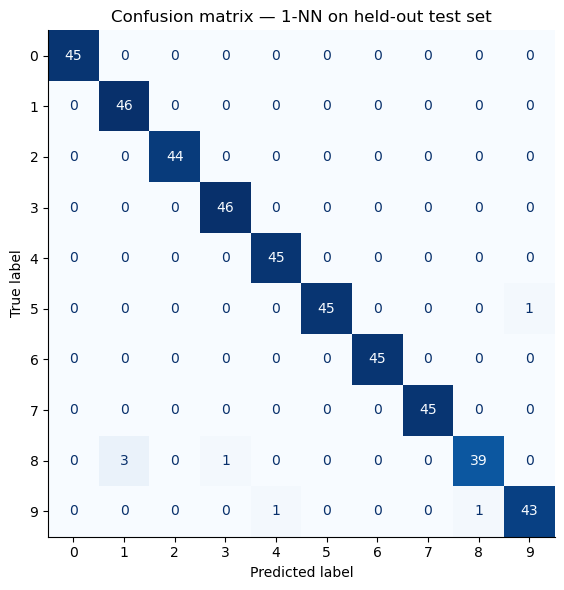

In [19]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix — 1-NN on held-out test set")
ax.grid(False)
plt.tight_layout()
plt.show()


## 9. Robustness under noise

Real inputs are never byte-clean. Cameras have noise. Users draw differently. Floats round.

A useful retrieval system should degrade *gracefully* — accuracy that falls off slowly as noise grows, not a cliff. We test that by sweeping Gaussian noise into the held-out test set and measuring accuracy at each level.

### A single noisy query

Start with one example so you can see what the retrieval system is actually doing.


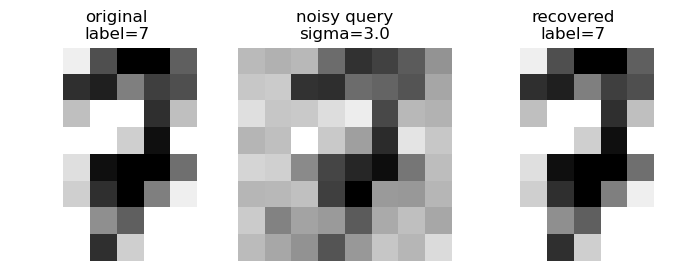

{'label': 7, 'distance': 21.41668473841197, 'exact': False, 'matched_index': 300}
Correct? True


In [20]:
rng         = np.random.default_rng(7)
i           = 300
noise_sigma = 3.0

query  = X_all[i] + rng.normal(0, noise_sigma, size=64)
result = mem.query(query)
nn_img = digits.images[result["matched_index"]]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.7))
axes[0].imshow(digits.images[i], cmap="gray_r")
axes[0].set_title(f"original\nlabel={y_all[i]}")
axes[1].imshow(query.reshape(8, 8), cmap="gray_r")
axes[1].set_title(f"noisy query\nsigma={noise_sigma}")
axes[2].imshow(nn_img, cmap="gray_r")
axes[2].set_title(f"recovered\nlabel={result['label']}")
for ax in axes:
    ax.axis("off")
    ax.grid(False)
plt.tight_layout()
plt.show()

print(result)
print("Correct?", result["label"] == int(y_all[i]))


### The full degradation curve

How far can we push it before the system breaks? We sweep sigma from 0 to 10 (pixel intensities are bounded 0..16, so σ=10 is noise on the same scale as the signal).


In [21]:
noise_levels = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0]
rng          = np.random.default_rng(0)

rows = []
for sigma in noise_levels:
    noisy = X_test + rng.normal(0, sigma, size=X_test.shape)
    p     = np.array([mem_eval.query(q)["label"] for q in noisy])
    rows.append({"noise_sigma": sigma, "accuracy": (p == y_test).mean()})

stress = pd.DataFrame(rows)
print(stress.to_string(index=False))


 noise_sigma  accuracy
         0.0     0.984
         0.5     0.982
         1.0     0.982
         2.0     0.984
         3.0     0.973
         4.0     0.964
         5.0     0.938
         7.0     0.847
        10.0     0.671


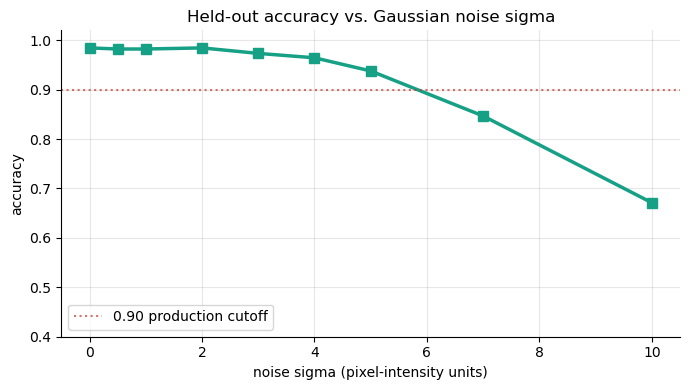

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    stress["noise_sigma"], stress["accuracy"],
    marker="s", color="#16a085", linewidth=2.5, markersize=7,
)
ax.axhline(
    y=0.90, color="#c0392b", linestyle=":", alpha=0.7,
    label="0.90 production cutoff",
)
ax.set_title("Held-out accuracy vs. Gaussian noise sigma")
ax.set_xlabel("noise sigma (pixel-intensity units)")
ax.set_ylabel("accuracy")
ax.set_ylim(0.4, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


Pixel values live in `[0, 16]`. At σ = 5 we're injecting noise at roughly a third of the signal's standard deviation, and accuracy is still above 90%. At σ = 10 — noise at the same scale as the signal — we're still getting two-thirds of queries right.

That's the curve you want for a retrieval system going to production: smooth degradation, no cliff.

---


## 10. Persistence — SQLite + CSV

So far the index lives entirely in RAM. For real deployment we'd like the dataset to survive a restart and be reproducible across runs.

The pattern we use in the repo's [`digits_memory.py`](../digits_memory.py) is:

1. **One-time download.** On first run, `load_digits()` is called and the result is written to `digits.db` (SQLite) and `digits.csv` (plain CSV, for cross-language use).
2. **Subsequent runs are fully offline.** We never hit `sklearn.datasets` again. The script reconstructs the in-memory index from the SQLite blob.
3. **CSV export is for the C version.** The C implementation in Module 11 reads the CSV — no `sklearn`, no numpy, no Python.

The SQLite schema is one table:

| column | type | role |
|---|---|---|
| `id` | INTEGER PRIMARY KEY | row index |
| `features` | BLOB | `np.array(64 doubles).tobytes()` |
| `label` | INTEGER | digit 0..9 |

The interesting trick is that we serialize the feature vector with the *same* `tobytes()` we used as the hash key. Round-tripping is symmetric:

```python
# write
cur.execute("INSERT INTO digits VALUES (?, ?, ?)", (i, X[i].tobytes(), int(y[i])))

# read
np.frombuffer(blob, dtype=np.float64)
```

Let's run the round-trip in this notebook to prove it works.


In [23]:
DB_PATH = "/tmp/digit_memory_course_demo.db"

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
conn.execute(
    "CREATE TABLE digits ("
    "id INTEGER PRIMARY KEY, "
    "features BLOB NOT NULL, "
    "label INTEGER NOT NULL)"
)
conn.executemany(
    "INSERT INTO digits VALUES (?, ?, ?)",
    [(i, X_all[i].tobytes(), int(y_all[i])) for i in range(len(y_all))],
)
conn.commit()

# Round-trip read
rows = conn.execute("SELECT features, label FROM digits LIMIT 3").fetchall()
for i, (blob, label) in enumerate(rows):
    vec = np.frombuffer(blob, dtype=np.float64)
    assert vec.shape == (64,)
    assert np.array_equal(vec, X_all[i])
    print(f"row {i}: label={label}, first 8 features={vec[:8]}")

conn.close()
print(f"\nDB size: {os.path.getsize(DB_PATH) / 1024:.1f} KB for 1797 samples")


row 0: label=0, first 8 features=[ 0.  0.  5. 13.  9.  1.  0.  0.]
row 1: label=1, first 8 features=[ 0.  0.  0. 12. 13.  5.  0.  0.]
row 2: label=2, first 8 features=[ 0.  0.  0.  4. 15. 12.  0.  0.]

DB size: 1036.0 KB for 1797 samples


1797 samples × (64 × 8 bytes + a few bookkeeping bytes) ≈ ~1 MB. Trivially storable on any device.

The CSV export is just `np.savetxt` of the same matrix with the label appended as the last column. The C version in the next module reads this file line by line.

---


## 11. The same system, in C

Writing the same system three ways is the closest I've found to actually understanding it.

- **Python with sklearn** is where you reach for first. Indexes are imported, not implemented. You write the *logic* of the system and trust the library to do the hard parts.
- **A Jupyter study notebook** is where you slow down — exactly what we're doing here.
- **Pure C** is where you find out what you actually understood. There's no `dict`, so you implement an open-addressed hash table with FNV-1a hashing. There's no `KDTree`, so you write a brute-force scan with `memcmp` for the byte compare. There's no `numpy`, so you write the loop. Every byte of memory is yours.

The repo's [`digits_memory.c`](../digits_memory.c) is 179 lines. Here's the part that matters — the hash table and the brute-force NN inner loop.

> **Honesty note.** The C version uses portable, unvectorized C. Some earlier iterations of this project's writeups claimed ARM NEON SIMD intrinsics; the code in the repo does *not* contain any. The reason it's still competitive with the Python version is that the brute-force inner loop is tiny (64 doubles, predictable branches) and compiles to good auto-vectorized code under `-O2` on modern compilers.


In [24]:
C_PATH = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), "digits_memory.c"))
# When run from course/ this resolves to repo_root/digits_memory.c.
# Fall back to the relative path if needed.
if not os.path.exists(C_PATH):
    C_PATH = os.path.abspath("../digits_memory.c")
if not os.path.exists(C_PATH):
    C_PATH = os.path.abspath("digits_memory.c")

with open(C_PATH) as f:
    c_source = f.read()

# Print the hash + NN core: lines 37..129
lines = c_source.splitlines()
print(f"=== {C_PATH} (lines 37..129) ===\n")
for n, line in enumerate(lines[36:129], start=37):
    print(f"{n:>3}: {line}")


=== /Users/nimitjain/Desktop/First_project/ML_projects/.claude/worktrees/sharp-lamarr-cafef5/digits_memory.c (lines 37..129) ===

 37: /* FNV-1a 64-bit over the raw byte representation of the features. */
 38: static uint64_t hash_features(const double *f) {
 39:     const unsigned char *p = (const unsigned char *)f;
 40:     uint64_t h = 1469598103934665603ULL;
 41:     for (size_t i = 0; i < sizeof(double) * N_FEATURES; i++) {
 42:         h ^= p[i];
 43:         h *= 1099511628211ULL;
 44:     }
 45:     return h;
 46: }
 47: 
 48: static int features_equal(const double *a, const double *b) {
 49:     return memcmp(a, b, sizeof(double) * N_FEATURES) == 0;
 50: }
 51: 
 52: static void hash_insert(int idx) {
 53:     uint64_t h = hash_features(samples[idx].features);
 54:     size_t   slot = h & (HASH_SIZE - 1);
 55:     while (hash_table[slot] != -1) {
 56:         slot = (slot + 1) & (HASH_SIZE - 1);
 57:     }
 58:     hash_table[slot] = idx;
 59: }
 60: 
 61: static int hash_find

A few details worth narrating:

- **`hash_features`** uses **FNV-1a** with the 64-bit offset basis and prime. The hash is computed byte-by-byte over the raw `double[64]` buffer — exactly the same bytes that Python's `arr.tobytes()` produces. The choice means Python and C use *byte-identical hash keys* for the same vector.
- **`hash_insert` / `hash_find`** implement **open-addressed linear probing**. The table is a power-of-two size (8192 slots for 1797 entries — ~22% load factor, plenty of headroom for probing) and `slot = h & (HASH_SIZE - 1)` is the fast modulo. On collision we walk to the next slot.
- **`features_equal`** is a single `memcmp` over `64 × 8 = 512` bytes. The compiler turns it into vectorized loads on any modern target.
- **`query`** does hash-find first; on miss it falls through to the brute-force scan. The inner loop is the textbook one: subtract, square, sum, keep the running min.

### Compile and run

If `gcc` (or `clang`) is on your PATH, we can build and execute the binary right from this notebook. We first need the CSV that the C version reads — `digits_memory.py` produces one in the same shape but for portability we'll regenerate it inline.


In [25]:
csv_path = "/tmp/digit_memory_course_demo.csv"
np.savetxt(
    csv_path,
    np.hstack([X_all, y_all.reshape(-1, 1)]),
    delimiter=",",
    fmt="%g",
)
print(f"Wrote {csv_path}  ({os.path.getsize(csv_path) / 1024:.1f} KB)")


compiler = shutil.which("gcc") or shutil.which("clang")
if compiler is None:
    print("\nNo C compiler on PATH — skipping the build step.")
    print("Install gcc or clang and re-run this cell to see the C binary in action.")
else:
    bin_path = "/tmp/digit_memory_course_demo"
    build = subprocess.run(
        [compiler, "-O2", "-o", bin_path, C_PATH, "-lm"],
        capture_output=True, text=True,
    )
    if build.returncode != 0:
        print("Build failed:\n", build.stderr)
    else:
        print(f"Built {bin_path} with {compiler} -O2\n")
        run = subprocess.run(
            [bin_path, csv_path], capture_output=True, text=True,
        )
        print(run.stdout)
        if run.stderr:
            print("[stderr]", run.stderr)


Wrote /tmp/digit_memory_course_demo.csv  (258.5 KB)
Built /tmp/digit_memory_course_demo with /usr/bin/gcc -O2



Loaded 1797 samples from /tmp/digit_memory_course_demo.csv

exact              label=1  dist=0.0000  exact=1  (2.0 us)
perturbed          label=1  dist=1.4765  exact=0  (90.0 us)
noisy              label=4  dist=9.1724  exact=0  (87.0 us)



The latencies the C binary prints aren't dramatically different from Python's. That's the point. The Python version is fast because the heavy lifting — the dict, the BallTree, the numpy subtraction — is already in compiled C inside the interpreter. Rewriting the *outer logic* in C doesn't unlock a new order of magnitude.

The payoff of the C version isn't speed — it's that there is nowhere to hide. If you don't understand how an open-addressed hash table handles collisions, your code crashes. If you don't understand how to read floats from a CSV, your distances are garbage. Forty extra lines, and every byte is yours.

---


## 12. Parametric baselines — Logistic Regression and an MLP

So far we've classified by lookup. The standard alternative is to **train a model**: define a loss, take gradients, update weights. Let's do that on the same train/test split and put the numbers next to each other.

We'll measure two axes — held-out accuracy and per-query inference latency.

### Logistic Regression

For 64-dim features and 10 classes, a multinomial logistic regression has $64 \times 10 + 10 = 650$ parameters. It's the smallest "real" model you can fit, and it's a strong baseline for digits.


In [26]:
logreg = LogisticRegression(max_iter=2000, multi_class="auto")
t0 = time.perf_counter()
logreg.fit(X_train, y_train)
logreg_train_s = time.perf_counter() - t0

preds_lr     = logreg.predict(X_test)
logreg_acc   = (preds_lr == y_test).mean()

# Inference latency, one query at a time
t0 = time.perf_counter()
for q in X_test:
    logreg.predict(q.reshape(1, -1))
logreg_us = (time.perf_counter() - t0) * 1e6 / len(X_test)

print(f"LogReg train time : {logreg_train_s:.2f} s")
print(f"LogReg accuracy   : {logreg_acc:.4f}  ({logreg_acc * 100:.2f}%)")
print(f"LogReg us/query   : {logreg_us:.1f}")


LogReg train time : 0.06 s
LogReg accuracy   : 0.9622  (96.22%)
LogReg us/query   : 19.1


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### A small MLP

64 → 64 → 32 → 10, ReLU activations, Adam. Roughly 6,500 parameters — still tiny, easily trainable on a CPU in seconds.


In [27]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=0,
)
t0 = time.perf_counter()
mlp.fit(X_train, y_train)
mlp_train_s = time.perf_counter() - t0

preds_mlp = mlp.predict(X_test)
mlp_acc   = (preds_mlp == y_test).mean()

t0 = time.perf_counter()
for q in X_test:
    mlp.predict(q.reshape(1, -1))
mlp_us = (time.perf_counter() - t0) * 1e6 / len(X_test)

print(f"MLP train time : {mlp_train_s:.2f} s")
print(f"MLP accuracy   : {mlp_acc:.4f}  ({mlp_acc * 100:.2f}%)")
print(f"MLP us/query   : {mlp_us:.1f}")


MLP train time : 0.26 s
MLP accuracy   : 0.9600  (96.00%)
MLP us/query   : 29.3


### Side-by-side

The 1-NN engine ("memory") needs no training, so we report training time as zero. Inference latency comes from the timing loop we ran inside the `DigitMemory.query` path in Module 7.


In [28]:
# Re-measure memory inference latency cleanly on the test set
t0 = time.perf_counter()
for q in X_test:
    mem_eval.query(q)
mem_us = (time.perf_counter() - t0) * 1e6 / len(X_test)

comparison = pd.DataFrame([
    {
        "model":          "1-NN memory (hybrid)",
        "train_time_s":   0.0,
        "test_accuracy":  round(accuracy, 4),
        "us_per_query":   round(mem_us, 1),
        "params":         "0 (stores 1347 vectors)",
    },
    {
        "model":          "Logistic Regression",
        "train_time_s":   round(logreg_train_s, 2),
        "test_accuracy":  round(logreg_acc, 4),
        "us_per_query":   round(logreg_us, 1),
        "params":         "650",
    },
    {
        "model":          "MLP (64-32)",
        "train_time_s":   round(mlp_train_s, 2),
        "test_accuracy":  round(mlp_acc, 4),
        "us_per_query":   round(mlp_us, 1),
        "params":         "~6,500",
    },
])
print(comparison.to_string(index=False))


               model  train_time_s  test_accuracy  us_per_query                  params
1-NN memory (hybrid)          0.00          0.984          39.4 0 (stores 1347 vectors)
 Logistic Regression          0.06          0.962          19.1                     650
         MLP (64-32)          0.26          0.960          29.3                  ~6,500


On this dataset, the three numbers are remarkably close. Tiny differences in accuracy come down to which examples each method happens to get right, and the differences in latency depend mostly on what the inference call has to do *outside* the math — argmax over a 64-d query for 1-NN, a matrix–vector multiply for LogReg, two matrix–vector products plus ReLU for the MLP.

This is the "established a real baseline" payoff of retrieval: before you build a model, *try the lookup.* If it gets you within a fraction of a percent, you have a baseline that's free, deterministic, and trivially explainable.

---


## 13. When retrieval stops being enough

The whole story above hinges on a dataset that fits in RAM and a query distribution where exact matches and close neighbors are common. As either of those assumptions breaks, the design changes.

### Scale arithmetic

| Dataset | N | Features | Storage at float64 |
|---|---:|---:|---:|
| `sklearn` digits (this course) | 1,797 | 64 | ~0.9 MB |
| MNIST | 70,000 | 784 | ~440 MB |
| CIFAR-10 | 60,000 | 3,072 | ~1.5 GB |
| ImageNet (classification) | ~1.2 M | ~150,528 (224×224×3) | ~1.4 TB |

The hash-map cost is independent of N for hits. The brute-force scan is **O(N · d) per query**. At sklearn-digits scale that's `1797 × 64 ≈ 115k` floating-point ops per query — done in the microseconds we measured. At MNIST scale it's `60,000 × 784 ≈ 47 M` ops — still fast on vectorized hardware. At ImageNet scale, it's 180 G-FLOPs per query, which is no longer "free."

### Approximate nearest neighbor

Once exact NN becomes the bottleneck, the standard move is to trade a small amount of accuracy for orders of magnitude in latency. Three production-grade libraries:

- **FAISS** (Facebook AI Similarity Search) — IVF, HNSW, PQ. The de-facto standard for billion-scale vector search.
- **HNSW** (Hierarchical Navigable Small World graphs) — graph-based, fast query, expensive build. Powers most modern vector databases.
- **Annoy** (Spotify) — multiple random projection trees, simple to use, small dependency footprint.

All three return *approximate* nearest neighbors with tunable recall (typically 90–99%) at query latencies in the microsecond-to-low-millisecond range even on billion-vector indexes.

### When to reach for a model

For images, text, audio, or anything where the raw feature representation is *not* meaningfully close to perceptual similarity, retrieval-on-raw-pixels is the wrong baseline. You want a **learned representation** — a model trained to embed inputs into a space where Euclidean (or cosine) distance reflects what you actually care about. Once you have that embedding, retrieval becomes the natural inference step again, just over a different vector.

The decision matrix is roughly:

| Situation | Use |
|---|---|
| Small N, raw features carry signal | 1-NN memory (this course) |
| Repeated/cached queries dominate | Hash map alone is enough |
| Large N, exact NN too slow | Approximate NN (FAISS / HNSW) |
| Raw features don't reflect similarity | Train an embedding, then retrieve |
| You want calibrated probabilities | A parametric model |
| You need cross-feature interactions | A model — likely an MLP or CNN |

### GPUs and Tensor Cores

For the *parametric* branch of the matrix above, GPU acceleration matters once the model gets big. CPU memory bandwidth is ~50–100 GB/s; a modern data-center GPU like an H100 is roughly 30× that at ~3 TB/s, with Tensor Cores adding another order of magnitude of throughput on dense matrix multiplies. For small models on small inputs — the digits in this course, a small MLP — the GPU launch overhead dominates and CPU inference is the faster path. For deep convolutional networks on full-resolution images, the curve flips.

The retrieval system in this course never needs a GPU. The parametric baselines in Module 12 wouldn't see one either, on this dataset. The architecture matters when the dataset and model grow, not before.

---


## 14. Engineering lessons

The five things I'll take from building this system three ways.

1. **Retrieval is a criminally underused baseline.** Before you train anything, ask whether you can just remember the answer. On problems with small-to-medium data, the answer is often yes. When it's not, you've still established a real number the model has to beat.

2. **Match the structure to the query distribution.** If most of your queries are repeats, a hash table is the right answer regardless of what your data looks like. If your queries are always novel, you can skip the cache. Hybrid systems beat either alone.

3. **Benchmark before you assume.** Whether a tree beats a hand-written brute-force loop at small N is *implementation-dependent and machine-dependent* — sklearn's tightly-optimized C trees can outperform a naive Python brute force by 5–10×, while a more carefully-vectorized brute force can close the gap. The textbook claim "trees are faster" is true asymptotically; in the constants where production code lives, you find out by measuring. The cost of measuring is always less than the cost of being wrong.

4. **Hash-key choice matters.** `tuple(array)` looks innocent and is slow. `array.tobytes()` is fast, deterministic, and survives serialization. The difference is measurable and the right answer is unambiguous.

5. **Writing the same system in multiple languages compounds your understanding.** Python lets you build it. The notebook makes you reason about it. C makes you understand it. There is no faster path to internalizing a data structure than to implement it yourself in a language that does not give it to you.

---


## 15. Extensions and further work

If you want to keep pulling on this thread, each of these is a one-afternoon experiment.

- **Cosine distance instead of Euclidean.** For grayscale digits the difference is small; for normalized embeddings it can be the whole game. Drop in `sklearn.neighbors.BallTree(metric="cosine")` and re-run the held-out accuracy.

- **PCA before indexing.** Reduce 64 dimensions to 16 with `sklearn.decomposition.PCA` and re-measure. Tree-traversal speed should improve; accuracy will drop slightly. Quantifying the tradeoff is a few cells.

- **k-NN instead of 1-NN.** Vote among the top-`k` neighbors. Usually a small accuracy bump, especially in the high-noise regime of Module 9 where a single near-miss can swing the answer.

- **A rejection threshold.** If the nearest neighbor's distance is above some cutoff, return "unknown" instead of guessing. Calibrate the cutoff from the noisy stress test in Module 9 — the right number is the one where wrong-but-confident answers stop costing more than abstentions.

- **Approximate NN.** Once you scale past a million samples, exact NN becomes the bottleneck. Swap the BallTree for FAISS or HNSW and re-measure. The accuracy / latency tradeoff curve is the interesting object.

- **Embedding-based retrieval.** Train a small encoder (LeNet-style CNN, or a contrastive model) on the digits and retrieve over the embedding space instead of raw pixels. The robustness curve in Module 9 will flatten dramatically — pixel-level noise no longer translates to embedding-level distance.

---

## Where to go from here

The code, notebooks, and C source are all in this repository. Three good entry points:

- [`digits_memory.py`](../digits_memory.py) — the cleanest single-file summary.
- [`digits_memory.c`](../digits_memory.c) — the deepest understanding.
- This notebook — the longest exposition.

The whole system is a few hundred lines. The hardest part wasn't writing it. The hardest part was deciding which questions were worth measuring.

---

*Built with `numpy`, `scikit-learn`, `pandas`, `matplotlib`, and a C compiler.*
